In [2]:
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark graphframes
!wget https://snap.stanford.edu/data/facebook_large.zip
!unzip -o facebook_large.zip

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
--2025-12-03 20:34:26--  https://snap.stanford.edu/data/facebook_large.zip
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1737479 (1.7M) [application/zip]
Saving to: ‘facebook_large.zip’

facebook_large.zip  100%[===================>]   1.66M  1.18MB/s    in 1.4s    

2025-12-03 20:34:27 (1.18 MB/s) - ‘facebook_large.zip’ saved [1737479/1737479]

Archive:  facebook_large.zip
   creating: facebook_large/
  inflating: facebook_large/musae_facebook_edges.csv  
  inflating: facebook_large/musae_facebook_features.json  
  inflating: facebook_large/musae_facebook_target.csv  
  inflating: facebook_large/citing.txt  
  inflating: facebook_large/README.tx

In [3]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("GraphFramesHomework") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12") \
    .getOrCreate()

sc = spark.sparkContext
sc.setCheckpointDir("/tmp/graphframes-checkpoint")
print(f"Spark version: {spark.version}")

Spark version: 3.5.1


In [4]:
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pyspark.shell import spark
from pyspark.sql import DataFrame, SparkSession
from pyspark.sql.functions import (
    col, desc, count, lit, when, coalesce, sum, greatest, max, rand
)

from graphframes import graphframe
from graphframes.examples import Graphs
from graphframes.lib import Pregel
from graphframes import *

Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.5.1
      /_/

Using Python version 3.12.12 (main, Oct 10 2025 08:52:57)
Spark context Web UI available at http://774edd881322:4040
Spark context available as 'sc' (master = local[*], app id = local-1764794087148).
SparkSession available as 'spark'.


/tmp/spark-ec3c55b3-be8b-4ffa-8919-512f08b19773/userFiles-97417ae4-7c13-4652-af03-7eda878b44d5/graphframes_graphframes-0.8.3-spark3.5-s_2.12.jar/graphframes/examples/belief_propagation.py:45: SyntaxWarning: invalid escape sequence '\ '
/tmp/spark-ec3c55b3-be8b-4ffa-8919-512f08b19773/userFiles-97417ae4-7c13-4652-af03-7eda878b44d5/graphframes_graphframes-0.8.3-spark3.5-s_2.12.jar/graphframes/examples/belief_propagation.py:45: SyntaxWarning: invalid escape sequence '\ '
/tmp/spark-ec3c55b3-be8b-4ffa-8919-512f08b19773/userFiles-97417ae4-7c13-4652-af03-7eda878b44d5/graphframes_graphframes-0.8.3-spark3.5-s_2.12.jar/graphframes/examples/graphs.py:64: SyntaxWarning: invalid escape sequence '\ '
/tmp/spark-ec3c55b3-be8b-4ffa-8919-512f08b19773/userFiles-97417ae4-7c13-4652-af03-7eda878b44d5/graphframes_graphframes-0.8.3-spark3.5-s_2.12.jar/graphframes/examples/graphs.py:64: SyntaxWarning: invalid escape sequence '\ '


In [5]:
spark = SparkSession.builder.appName("GraphFramesHomework").getOrCreate()
sc = spark.sparkContext

## Zadanie 1
Wczytać graf Facebooka, krawędzie z pliku musae_facebook_edges.csv, atrybuty page_name oraz page_type z pliku musae_facebook_target.csv.  Policzyć liczbę krawędzi i wierzchołków. (1 p.)

In [6]:
edges = spark.read.csv("./facebook_large/musae_facebook_edges.csv", header=True) \
    .withColumnRenamed("id_1", "src") \
    .withColumnRenamed("id_2", "dst")

edges.show()

+---+-----+
|src|  dst|
+---+-----+
|  0|18427|
|  1|21708|
|  1|22208|
|  1|22171|
|  1| 6829|
|  1|16590|
|  1|20135|
|  1| 8894|
|  1|15785|
|  1|10281|
|  1|22265|
|  1| 7136|
|  1|22405|
|  1|10379|
|  1|13737|
|  1| 8533|
|  1|14344|
|  1| 2812|
|  1| 5755|
|  1|16260|
+---+-----+
only showing top 20 rows



In [7]:
vertices = spark.read.csv("./facebook_large/musae_facebook_target.csv", header=True).select("id", "page_name", "page_type")
vertices.show()

+---+--------------------+----------+
| id|           page_name| page_type|
+---+--------------------+----------+
|  0|The Voice of Chin...|    tvshow|
|  1|U.S. Consulate Ge...|government|
|  2|                ESET|   company|
|  3|Consulate General...|government|
|  4|Mark Bailey MP - ...|politician|
|  5| Victor Dominello MP|politician|
|  6|Jean-Claude Poissant|politician|
|  7|Deputado Ademir C...|politician|
|  8|T.C. Mezar-ı Şeri...|government|
|  9|Army ROTC Fightin...|government|
| 10| NASA Student Launch|government|
| 11|       Eliziane Gama|politician|
| 12|     Socialstyrelsen|government|
| 13|Brisbane Water LA...|government|
| 14|NASA's Marshall S...|government|
| 15|Municipio de Loma...|government|
| 16|  Die Techniker (TK)|   company|
| 17|     Digvijaya Singh|politician|
| 18|1st Armored Divis...|government|
| 19|           Shapeways|   company|
+---+--------------------+----------+
only showing top 20 rows



In [8]:
g = GraphFrame(vertices, edges)
print(f"Liczba wierzchołków: {g.vertices.count()}")
print(f"Liczba krawędzi: {g.edges.count()}")

Liczba wierzchołków: 22470
Liczba krawędzi: 171002


## Zadanie 2
Sprawdzić czy graf jest spójny. Czy dwa podgrafy utworzone dla typów strony governmental organizations oraz television shows też są spójne? (1 p.)

In [9]:
sc.setCheckpointDir("/tmp/graphframes-homework-connected-components")

components = g.connectedComponents()
num_components = components.select("component").distinct().count()
print(f"Liczba składowych spójnych w całym grafie: {num_components}")

types = ["governmental organizations", "television shows"]
for page_type in types:
    subgraph_vertices = g.vertices.filter(f"page_type = '{page_type}'")
    subgraph = GraphFrame(subgraph_vertices, g.edges)

    sub_components = subgraph.connectedComponents()
    sub_num_components = sub_components.select("component").distinct().count()

    print(f"\nPodgraf dla typu {page_type}:")
    print(f"Liczba składowych spójnych: {sub_num_components}")

Liczba składowych spójnych w całym grafie: 1

Podgraf dla typu governmental organizations:
Liczba składowych spójnych: 0

Podgraf dla typu television shows:
Liczba składowych spójnych: 0


## Zadanie 3
Spośród 500 stron o najwyższym PageRank znaleźć 50 takich (wypisać page_name i page_type), które mają najmniej połączeń oraz 50 o największej liczbie połączeń. Który typ strony był dominujący w każdej z tych kategorii? Narysować wykres zależności PageRank od liczby krawędzi dla wierzchołków (scatter plot) (2 p.)

Dominujące typy dla 50 stron z najmniejszą liczbą połączeń:
+----------+-----+
| page_type|count|
+----------+-----+
|   company|   28|
|politician|   16|
|government|    4|
|    tvshow|    2|
+----------+-----+

Dominujące typy dla 50 stron z największą liczbą połączeń:
+----------+-----+
| page_type|count|
+----------+-----+
|government|   37|
|politician|   12|
|   company|    1|
+----------+-----+



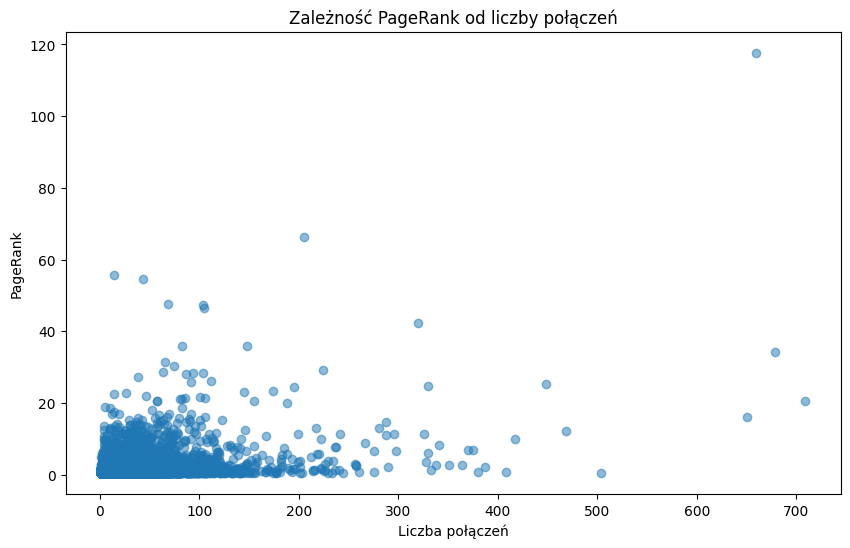

In [10]:
pagerank = g.pageRank(resetProbability=0.15, tol=0.01)
degrees = g.degrees

results = pagerank.vertices.join(degrees, "id").orderBy(desc("pagerank"))

top = results.limit(500)

bottom50 = top.orderBy("degree").limit(50)
top50 = top.orderBy(desc("degree")).limit(50)

print("Dominujące typy dla 50 stron z najmniejszą liczbą połączeń:")
bottom50.groupBy("page_type").count().orderBy(desc("count")).show()

print("Dominujące typy dla 50 stron z największą liczbą połączeń:")
top50.groupBy("page_type").count().orderBy(desc("count")).show()

results_pd = results.toPandas()
plt.figure(figsize=(10, 6))
plt.scatter(results_pd["degree"], results_pd["pagerank"], alpha=0.5)
plt.xlabel("Liczba połączeń")
plt.ylabel("PageRank")
plt.title("Zależność PageRank od liczby połączeń")
plt.show()

### 4
Korzystając z Pregel API zaimplementować następujący algorytm. W pierwszym kroku wybrana strona publikuje post fake news. W kolejnym kroku ten post publikowany jest przez 1/4 losowo wybranych kontaktów tej strony. W dalszych krokach, dla każdej strony, która opublikowała już ten post, losowo wybrane 1/4 jej kontaktów publikuje go u siebie. Pokazać jak zmienia się liczba stron które opublikowały post w zależności od liczby kroków. (2 p.)
Opcjonalnie: Sprawdzić powyższą zależność dla współczynnika innego niż 1/4.


Symulacja zakończona po 5 iteracjach.
Całkowita liczba wierzchołków: 22470
Liczba zainfekowanych wierzchołków w ostatniej iteracji: 4482



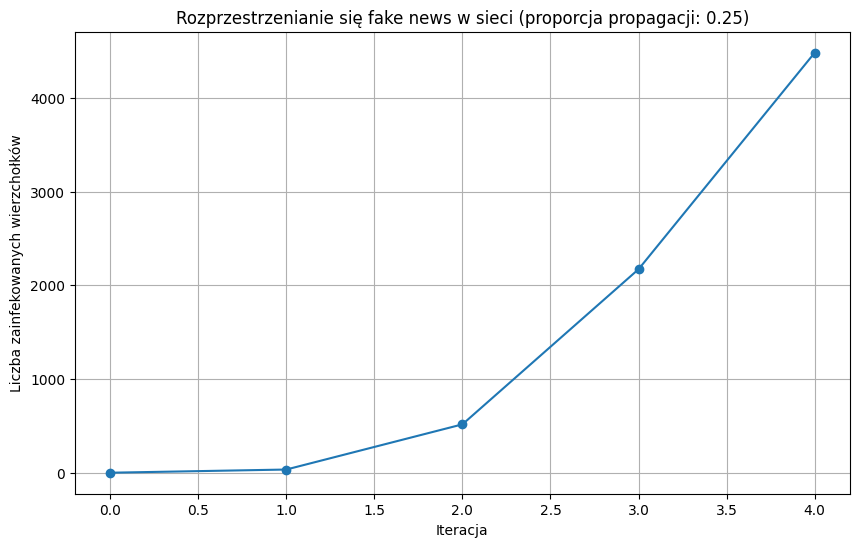

In [11]:
from pyspark.sql.functions import when, col, lit, rand, coalesce, greatest, max
from graphframes import GraphFrame
import matplotlib.pyplot as plt

def fake_news_simulation(graph, initial_vertex_id, propagation_ratio, max_iterations):
    vertices_with_activation = graph.vertices.withColumn(
        "activated",
        when(col("id") == initial_vertex_id, lit(1.0)).otherwise(lit(0.0))
    ).select("id", "activated")

    edges = graph.edges.select("src", "dst")

    initial_graph = GraphFrame(vertices_with_activation, edges)

    propagation_history = []
    result_graph = initial_graph

    for iteration in range(max_iterations):
        infected_count = result_graph.vertices.filter(col("activated") > 0).count()
        propagation_history.append(infected_count)

        pregel_result = result_graph.pregel \
            .setMaxIter(1) \
            .withVertexColumn(
                "new_activated",
                col("activated"),
                greatest(col("activated"),Pregel.msg() * lit(propagation_ratio))
            ) \
            .sendMsgToDst(
                when(Pregel.src("activated") > 0, lit(1.0)).otherwise(lit(0.0))
            ) \
            .aggMsgs(coalesce(max(Pregel.msg()), lit(0.0))) \
            .run()

        result_graph = GraphFrame(
            pregel_result.select(
                "id",
                col("new_activated").alias("activated")
            ),
            edges
        )

    total_vertices = vertices_with_activation.count()

    print(f"\nSymulacja zakończona po {max_iterations} iteracjach.")
    print(f"Całkowita liczba wierzchołków: {total_vertices}")
    print(f"Liczba zainfekowanych wierzchołków w ostatniej iteracji: {propagation_history[-1]}\n")

    plt.figure(figsize=(10, 6))
    plt.plot(range(max_iterations), propagation_history, marker='o')
    plt.xlabel("Iteracja")
    plt.ylabel("Liczba zainfekowanych wierzchołków")
    plt.title(f"Rozprzestrzenianie się fake news w sieci (proporcja propagacji: {propagation_ratio})")
    plt.grid(True)
    plt.show()

    return result_graph


result = fake_news_simulation(g, initial_vertex_id="1",propagation_ratio=0.25, max_iterations=5 )

### 5
Narysować wykres rozkładu stopnia wierzchołków w grafie w skali logarytmicznej. Można skorzystać z metody stat.approxQuantile. Czy sieć jest bezskalowa (scale-free)? https://barabasi.com/f/623.pdf  (2 p.)

Współczynnik kierunkowy (gamma): 1.87
R^2: 0.91

Sieć nie jest bezskalowa


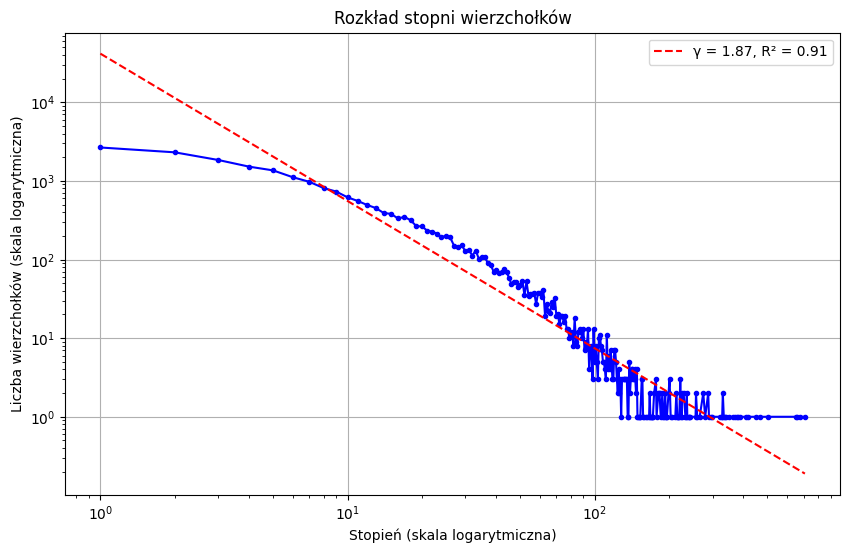

In [12]:
degrees = g.degrees
degree_dist = degrees.groupBy("degree").count().orderBy("degree")
degree_dist_pd = degree_dist.toPandas()

plt.figure(figsize=(10, 6))
plt.loglog(degree_dist_pd["degree"], degree_dist_pd["count"], 'bo-', markersize=3)
plt.xlabel("Stopień (skala logarytmiczna)")
plt.ylabel("Liczba wierzchołków (skala logarytmiczna)")
plt.title("Rozkład stopni wierzchołków")
plt.grid(True)

log_degrees = np.log(degree_dist_pd["degree"])
log_counts = np.log(degree_dist_pd["count"])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_degrees, log_counts)

print(f"Współczynnik kierunkowy (gamma): {-slope:.2f}")
print(f"R^2: {r_value**2:.2f}")
print(f"\nSieć {'jest' if -3 < slope < -2 and r_value**2 > 0.8 else 'nie jest'} bezskalowa")

plt.plot(degree_dist_pd["degree"],
    np.exp(intercept + slope * log_degrees),
    'r--',
    label=f'γ = {-slope:.2f}, R² = {r_value**2:.2f}')
plt.legend()
plt.show()

**Sieć nie jest bezskalowa (scale-free)** z dwóch powodów:

- **Współczynnik γ (gamma) jest poza oczekiwanym zakresem**:

    Dla sieci bezskalowych współczynnik kierunkowy γ (gamma) w skali logarytmicznej powinien być w zakresie między -2 a -3 (czyli 2 < γ < 3 dla wartości bezwzględnej)
  
    W naszym przypadku γ = 1.87, co jest poza tym zakresem

- **Rozkład stopni nie jest ściśle zgodny z prawem potęgowym**:

    Choć wartość R² = 0.91 jest dość wysoka (dobra zgodność z linią prostą w skali logarytmicznej)
  
    W sieciach bezskalowych rozkład stopni wierzchołków powinien ściśle podążać za prawem potęgowym P(k) ∝ k^(-γ)